# 使用 TEDD 进行可视化

本节介绍使用 TEDD (Tensor Expression Debug Display) 可视化张量表达式。

加载一些库:

In [1]:
# import tvm
from tvm import te
from tvm.contrib import tedd
from IPython.display import display_svg

定义 `add` 计算和调度:

In [2]:
A = te.placeholder((1,), name="A")
B = te.placeholder((1,), name="B")
C = A + B

s = te.create_schedule(C.op)

## 数据流图

查看计算过程以及调度的流程图:

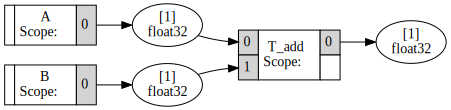

In [7]:
tedd.viz_dataflow_graph(s, show_svg=True)

```{note}
每个节点表示一个阶段，中间显示名称和 memory scope，两侧显示 inputs/outputs 信息。边表示节点的依赖关系。
```

## 调度树

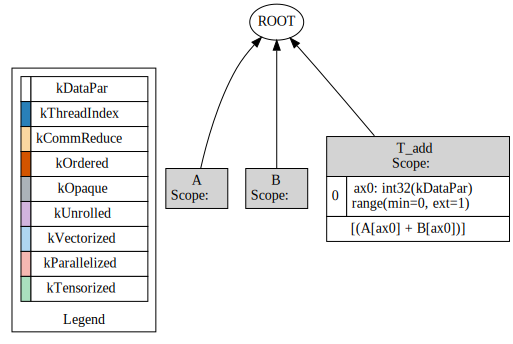

In [4]:
tree = tedd.viz_schedule_tree(s, show_svg=True)
# tedd.viz_schedule_tree(s, dot_file_path="/tmp/scheduletree.dot") # 保存到本地
display_svg(tree)

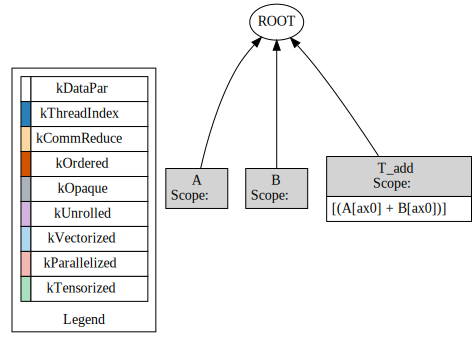

In [5]:
s = s.normalize()
# tedd.viz_schedule_tree(s, dot_file_path="/tmp/scheduletree2.dot")
tree = tedd.viz_schedule_tree(s, show_svg = True)
display_svg(tree)

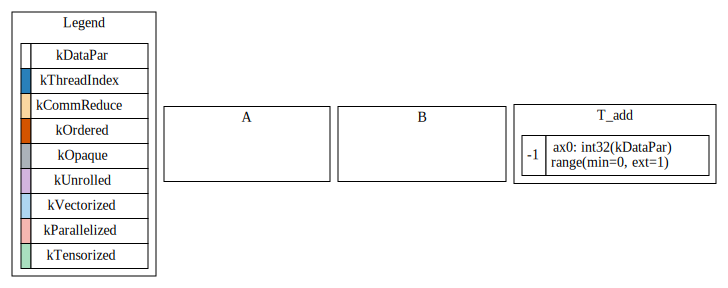

In [6]:
# tedd.viz_itervar_relationship_graph(s, dot_file_path="/tmp/itervar.dot")
graph = tedd.viz_itervar_relationship_graph(s, show_svg = True)
display_svg(graph)